In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import euclidlib as el

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.FlamingoBaryonResponseEmulator_cosmology import CAMBNonLinearFLAMINGOPerturbations
from cloelib.observables.photo import ShearTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

In [2]:
# Cosmology parameters - fiducial FLAMINGO cosmology
H0 =  68.1
h = H0/100.
sigma8 = 0.807
Omega_cdm0 = (0.306-0.0486)
omch2 = Omega_cdm0*h**2 
Omega_b0 = 0.0486 
ombh2 = Omega_b0*h**2 
Omega_k0 = 0.
w = -1.
wa = 0.
ns = 0.967
mnu = 0.06
As=2.099e-9
Tcmb = 2.7255
Neff = 3.046
YHe = 0.248

In [3]:
# redshift and wavenumbers
zs = np.linspace(1e-4, 3, 100)
ks = np.logspace(np.log10(10**-4), np.log10(10**1.5), 100) #h/Mpc

In [4]:
#Initialise CAMB background instance
camb_instance = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=0., w0=-1.0, wa=0.0, 
                               gamma_MG=0.0)

In [5]:
# Baryonic suppression prediction from FLAMINGO, fiducial and strong feedback
fgas_sigma_fid, Mstar_sigma_fid,jet_fraction_fid = 0,0,0 
baryon_correction_flamingo = CAMBNonLinearFLAMINGOPerturbations(background=camb_instance, redshifts=zs, 
                            fgas_sigma=fgas_sigma_fid, Mstar_sigma=Mstar_sigma_fid,jet_fraction=jet_fraction_fid,nonlinear_model='takahashi')
fiducial_feedback =  baryon_correction_flamingo.baryonic_suppression(zs,ks,k_hunit=True)

fgas_sigma_strong, Mstar_sigma_strong,jet_fraction_strong = -8,0,1
strong_baryon_correction_flamingo = CAMBNonLinearFLAMINGOPerturbations(background=camb_instance, redshifts=zs, 
                            fgas_sigma=fgas_sigma_strong, Mstar_sigma=Mstar_sigma_strong,jet_fraction=jet_fraction_strong,nonlinear_model='takahashi')
strong_feedback =  strong_baryon_correction_flamingo.baryonic_suppression(zs,ks,k_hunit=True)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


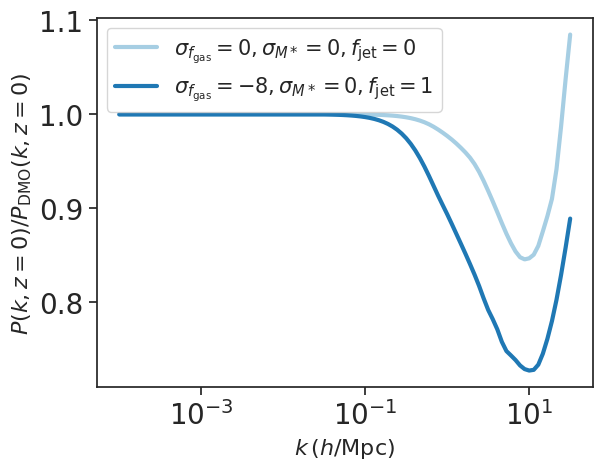

In [6]:
#FLAMINGO suppression of matter power spectrum
plt.semilogx(ks, fiducial_feedback[0,:], label= fr'$\sigma_{{f_\mathrm{{gas}}}} = {fgas_sigma_fid}, \sigma_{{M*}} = {Mstar_sigma_fid}, f_\mathrm{{jet}} = {jet_fraction_fid}$')
plt.semilogx(ks, strong_feedback[0,:], label= fr'$\sigma_{{f_\mathrm{{gas}}}} = {fgas_sigma_strong}, \sigma_{{M*}} = {Mstar_sigma_strong}, f_\mathrm{{jet}} = {jet_fraction_strong}$')
plt.xlabel(r'$k\, (h/$Mpc)', fontsize = 16)
plt.ylabel(r'$P(k,z=0) / P_\mathrm{DMO}(k,z=0)$', fontsize = 16)
plt.legend(fontsize = 15)

In [7]:
# CAMB PERTURBATIONS
camb_linear = CAMBLinearPerturbations(background=camb_instance, redshifts=zs)
camb_nonlinear = camb_nonlinear = CAMBNonLinearPerturbations(background=camb_instance, redshifts=zs, 
                                            nonlinear_model='takahashi')

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


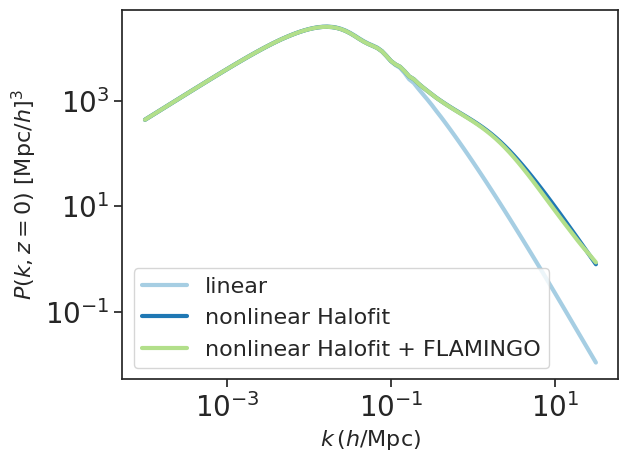

In [8]:
#Matter power spectra
linear_pk_camb = camb_linear.matter_power_spectrum(zs, ks, k_hunit=True, hubble_units=True)
nonlinear_pk_camb = camb_nonlinear.matter_power_spectrum(zs, ks, k_hunit=True, hubble_units=True)
nonlinear_pk_camb_with_flamingo = baryon_correction_flamingo.matter_power_spectrum(zs, ks, k_hunit=True, hubble_units=True)
plt.loglog(ks, linear_pk_camb[0, :], label= 'linear')
plt.loglog(ks, nonlinear_pk_camb[0, :], label= 'nonlinear Halofit')
plt.loglog(ks, nonlinear_pk_camb_with_flamingo[0, :], label= 'nonlinear Halofit + FLAMINGO')
plt.xlabel(r'$k\, (h/$Mpc)', fontsize = 16)
plt.ylabel(r'$P(k,z=0)$ [Mpc$/h$]$^{3}$', fontsize = 16)
plt.legend(fontsize = 16)

The baryon_correction_flamingo instance can then be passed on to the subsequent cloelib functions to generate observables just as CAMB could, for example for the shear-two point correlation functions

In [9]:
#Load n_z

# Execute this cell to download the data
data_downloaded = True

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)
z_nz, nz_example = el.photo.redshift_distributions('nz_example.fits')        

In [10]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

In [11]:
perturbations = camb_nonlinear

tracer_she = ShearTracer(perturbations=perturbations, 
                             dndz=my_dndz_she_norm,
                             z = zs,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41,
                                              'multiplicative_bias_1': 0.001, 'multiplicative_bias_2': 0.001,
                                              'multiplicative_bias_3': 0.001, 'multiplicative_bias_4': 0.001,
                                              'multiplicative_bias_5': 0.001, 'multiplicative_bias_6': 0.001,
                                              'dz_shear_1': 0.0001, 'dz_shear_2': 0.0001,
                                              'dz_shear_3': 0.0001, 'dz_shear_4': 0.0001,
                                              'dz_shear_5': 0.0001, 'dz_shear_6': 0.0001})

In [12]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)
cells_EE = twopoint_sheshe.get_Cl(ells, 0, perturbations.k)

In [13]:
ells_integration = np.arange(2, 30000)  # Multipole moments over which to integrate
# Define at which theta to evaluate the correlation function
theta_deg = np.geomspace(5, 100, 20)/60 # in degrees
theta_rad = np.deg2rad(theta_deg)  # in radians

# Initialize correlation function calculation object
correlation_function_EE = AngularCorrelationFunctionWigner(twopoint_sheshe, ells_integration, perturbations.k)


# Get correlation function at the defined thetas (NOTE: this takes the separation in radians!)
xi_sheshe_plus, xi_sheshe_minus = correlation_function_EE.get_xi(theta_rad)

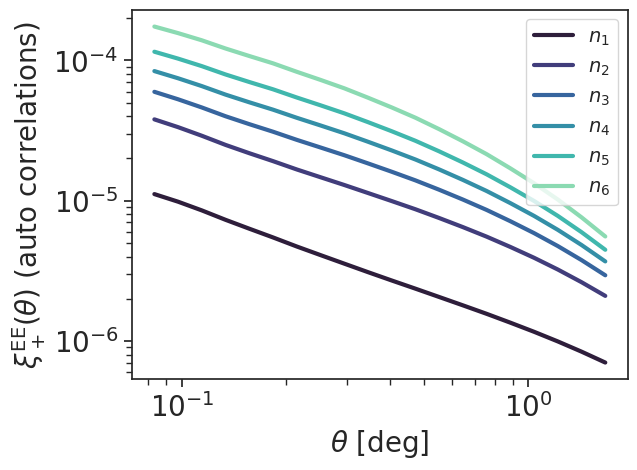

In [14]:
#shear two-point correlation functions
fig, ax = plt.subplots()


for i, color in zip(range(0, 6), sns.color_palette("mako", len(dndz_she_norm))):
    ax.loglog(theta_deg, xi_sheshe_plus[:, i, i], c=color,
              label=f"$n_{i+1}$")
    
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\xi^{\rm EE}_+(\theta)$ (auto correlations)')

ax.legend()